In [1]:
from epics import PV
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from time import sleep
from datetime import datetime

In [2]:
SSMBamplavg = PV('SCOPE1ZULP:h1p1:rdAmplAv')
SSMBampldev = PV('SCOPE1ZULP:h1p1:rdAmplDev')
SSMBavglen  = PV('SCOPE1ZULP:rdAvLength')

In [3]:
BPMx = PV('BPMZ1K3RP:rdX')
BPMx.get()

-2.1831568908691406

In [4]:
PC1 = PV('BME1VV:setVolt')
PC1.get()

2500.0

In [5]:
current = PV('mlsCurrent:Mnt3collectData.VALD')
current.get()

202.848228

In [6]:
u125gap = PV('U125IL2RP:BaseParGapsel.B')
u125go  = PV('U125IL2RP:BaseCmdCalc.PROC')

In [7]:
gaplist = np.arange(71.4,72.8,.05)
print(gaplist)

[71.4  71.45 71.5  71.55 71.6  71.65 71.7  71.75 71.8  71.85 71.9  71.95
 72.   72.05 72.1  72.15 72.2  72.25 72.3  72.35 72.4  72.45 72.5  72.55
 72.6  72.65 72.7  72.75]


In [8]:
def measure(direction):
    return pd.DataFrame({'time':datetime.now(), 'gap':gap, 'direction':direction,
                      'PC1':PC1.get(), 'orbitX':BPMx.get(), 'current':current.get(),
                      'SSMBavg':SSMBamplavg.get(), 'SSMBsem':SSMBampldev.get()/SSMBavglen.get()**0.5}, index=[0])

In [38]:
df = pd.DataFrame(columns=['time', 'gap', 'direction', 'PC1', 'orbitX', 'current', 'SSMBavg', 'SSMBsem'])

In [73]:
u125gap.put(gaplist[0])
u125go.put(1)
sleep(3)
for gap in gaplist:
    u125gap.put(gap)
    u125go.put(1)
    sleep(20)
    meas = measure('up')
    df = pd.concat((df, meas), ignore_index=True)
for gap in gaplist[::-1]:
    u125gap.put(gap)
    u125go.put(1)
    sleep(20)
    meas = measure('down')
    df = pd.concat((df, meas), ignore_index=True)
u125gap.put(72.21)
u125go.put(1)

1

In [74]:
df

,PC1,SSMBavg,SSMBsem,current,direction,gap,orbitX,time
0,4444.0,0.001914,0.000312,2177.223180,up,71.40,-0.868109,2024-07-16 10:49:32.332501
1,4444.0,0.002344,0.000334,2159.591280,up,71.45,-0.850802,2024-07-16 10:49:52.358815
2,4444.0,0.003252,0.000504,2141.778540,up,71.50,-0.856383,2024-07-16 10:50:12.385773
3,4444.0,0.004033,0.000319,2124.960420,up,71.55,-0.807689,2024-07-16 10:50:32.412035
4,4444.0,0.005986,0.000600,2108.323140,up,71.60,-0.794147,2024-07-16 10:50:52.436676
...,...,...,...,...,...,...,...,...
499,7570.0,0.004639,0.000717,20.049731,down,71.60,-2.629895,2024-07-16 14:55:58.885948
500,7570.0,0.002285,0.000193,19.994575,down,71.55,-2.624985,2024-07-16 14:56:18.911274
501,7570.0,0.000635,0.000394,19.949365,down,71.50,-2.587786,2024-07-16 14:56:38.936344
502,7570.0,0.000449,0.000215,19.886975,down,71.45,-2.608407,2024-07-16 14:56:58.961420


In [75]:
index=0
date ='2024-07-16'
df.to_hdf(f'{date}_U125scan_{index}.hdf5', key='data')

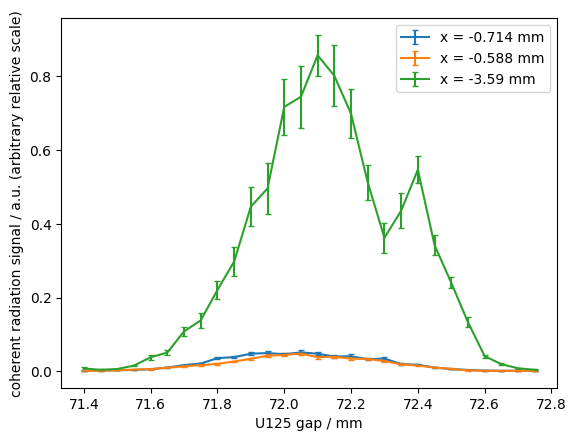

In [67]:
Plot = [3,4,5]
scales = [1,1,2.4,1,3,2.7,2.2,2.7,5,10,1,1,1,1,1,1]
for i, m, pl in zip(range(len(df)//len(gaplist)), scales, Plot):
    if pl:
        dfl = df.loc[i*len(gaplist):(i+1)*len(gaplist)-1]
        plt.errorbar(dfl.gap, dfl.SSMBavg*m, dfl.SSMBsem*m, capsize=2, marker='', ls='-', label=f'x = {dfl.orbitX.mean():#.3g} mm')
plt.legend()
plt.xlabel('U125 gap / mm')
plt.ylabel('coherent radiation signal / a.u. (arbitrary relative scale)')
plt.show()